In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
n = 800

temp = np.random.normal(75, 10, n)

vibration = np.random.normal(2.5, 1.0, n)

pressure = np.random.normal(30, 5, n)

rpm = np.random.normal(3000, 400, n)

run_hours = np.random.uniform(0, 5000, n)

In [ ]:
failure_score = (
    0.04 * (temp - 75)
    + 0.8 * (vibration - 2.5)
    + 0.0006 * run_hours
    - np.random.normal(0, 1, n)
)

failure = (failure_score > 1.2).astype(int)

In [ ]:
sensor_df = pd.DataFrame({
    "temperature_C": temp,
    "vibration_mm_s": vibration,
    "pressure_psi": pressure,
    "rpm": rpm,
    "run_hours": run_hours,
    "failure": failure
})

In [ ]:
print("Failure rate:", sensor_df["failure"].mean().round(3))

Failure rate: 0.56


In [ ]:
sensor_df.head()

,temperature_C,vibration_mm_s,pressure_psi,rpm,run_hours,failure
0,65.162782,4.321935,25.190246,3315.652820,108.793304,1
1,80.444897,2.667907,22.775062,2348.729763,1656.869529,0
2,79.084220,0.882714,25.746558,3596.549914,3962.817832,1
3,55.026012,1.364319,26.046273,3160.979074,1751.861167,0
4,79.812068,3.513062,24.758633,2825.830830,2967.701812,1


In [ ]:
sensor_df.shape

(800, 6)

In [ ]:
X = sensor_df.drop(columns=["failure"])
y = sensor_df["failure"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)

In [ ]:
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

In [ ]:
clf.fit(X_train_s, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [ ]:
preds = clf.predict(X_test_s)

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        preds,
        target_names=["Healthy", "Failure"]
    )
)

              precision    recall  f1-score   support

     Healthy       0.76      0.75      0.75        88
     Failure       0.81      0.81      0.81       112

    accuracy                           0.79       200
   macro avg       0.78      0.78      0.78       200
weighted avg       0.78      0.79      0.78       200



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

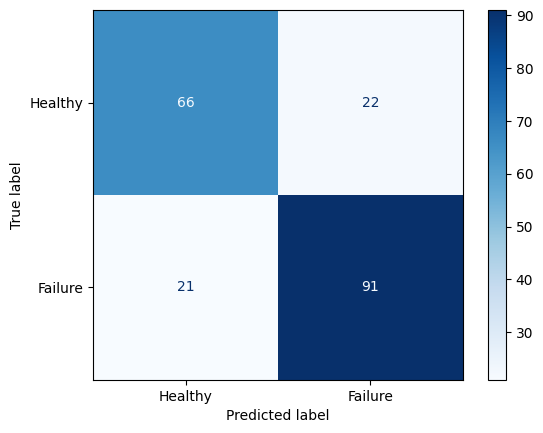

In [ ]:
cm = confusion_matrix(y_test, preds)

ConfusionMatrixDisplay(
    cm,
    display_labels=["Healthy", "Failure"]
).plot(cmap="Blues")

plt.show()